In [4]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from scipy.interpolate import RegularGridInterpolator

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
from devito import (Grid, Function, TimeFunction, VectorTimeFunction, 
                    TensorTimeFunction, div, grad, Eq, solve, Operator, 
                    norm, diag)
from examples.seismic import RickerSource, Receiver, TimeAxis

# --- Forward Model ---
def forward_elastic(vp, vs, rho, dx, dz, src_coords, rec_coords, f0, dt, t_max, nbl=40, so=4, scalar_src=False):
    """
    Robust 2D Elastic Forward Modeling with Automatic Padding & Coordinate Shifting.
    """
    # 1. Get Dimensions
    nx, nz = vp.shape
    
    # 2. Setup Padded Grid
    nx_pad = nx + 2 * nbl
    nz_pad = nz + nbl
    shape_pad = (nx_pad, nz_pad)
    extent_pad = ((nx_pad-1) * dx, (nz_pad-1) * dz)
    print(extent_pad)
    grid = Grid(shape=shape_pad, extent=extent_pad, origin=(0., 0.))
    x, z = grid.dimensions 

    # 3. Create & Fill Physical Parameters
    vp_f = Function(name='vp', grid=grid, space_order=so)
    vs_f = Function(name='vs', grid=grid, space_order=so)
    rho_f = Function(name='rho', grid=grid, space_order=so)

    # Fill boundaries 
    vp_f.data[:] = vp[0, 0] 
    vs_f.data[:] = vs[0, 0]
    rho_f.data[:] = rho[0, 0]

    # Fill Center (Physical Domain)
    vp_f.data[nbl:nbl+nx, 0:nz] = vp
    vs_f.data[nbl:nbl+nx, 0:nz] = vs
    rho_f.data[nbl:nbl+nx, 0:nz] = rho
    
    # Lame Parameters
    mu = Function(name='mu', grid=grid, space_order=so)
    lam = Function(name='lam', grid=grid, space_order=so)
    b = Function(name='b', grid=grid, space_order=so)

    mu.data[:] = rho_f.data * (vs_f.data**2)
    lam.data[:] = rho_f.data * (vp_f.data**2) - 2 * mu.data
    b.data[:] = 1.0 / rho_f.data

    time_range = TimeAxis(start=0, stop=t_max*1000, step=dt*1000)
    
    # 5. Coordinate Shifting 
    shift_x = nbl * dx
    shift_z = 0 
    
    src_coords_pad = np.array(src_coords, dtype=np.float32)
    src_coords_pad[:, 0] += shift_x
    src_coords_pad[:, 1] += shift_z
    
    rec_coords_pad = np.array(rec_coords, dtype=np.float32)
    rec_coords_pad[:, 0] += shift_x
    rec_coords_pad[:, 1] += shift_z

    # 6. Source & Receiver Objects
    src = RickerSource(name='src', grid=grid, f0=f0, 
                       npoint=src_coords.shape[0], time_range=time_range)
    src.coordinates.data[:] = src_coords_pad
    
    rec_vx = Receiver(name='rec_vx', grid=grid, npoint=rec_coords.shape[0], time_range=time_range)
    rec_vx.coordinates.data[:] = rec_coords_pad
    
    rec_vz = Receiver(name='rec_vz', grid=grid, npoint=rec_coords.shape[0], time_range=time_range)
    rec_vz.coordinates.data[:] = rec_coords_pad

    # 7. Damping (ABC)
    eta = Function(name='eta', grid=grid, space_order=0)
    damp_coeff = .05 / dt 
    eta_data = eta.data
    for i in range(nx_pad):
        for j in range(nz_pad):
            dist_left = max(0, nbl - i)
            dist_right = max(0, i - (nx_pad - nbl))
            dist_bottom = max(0, j - (nz - 1)) 
            dist = max(dist_left, dist_right, dist_bottom)
            if dist > 0:
                eta_data[i, j] = damp_coeff * (dist / nbl)**2

    # 8. Equation System
    v = VectorTimeFunction(name='v', grid=grid, space_order=so, time_order=1)
    tau = TensorTimeFunction(name='tau', grid=grid, space_order=so, time_order=1)
    
    u_v = Eq(v.forward, solve(v.dt - b * div(tau) + eta * v.forward, v.forward))
    u_tau = Eq(tau.forward, solve(tau.dt - lam * diag(div(v.forward)) - mu * (grad(v.forward) + grad(v.forward).transpose(inner=False)) + eta * tau.forward, tau.forward))

    bc = [Eq(tau[1, 1].forward.subs({z: 0}), 0.0), 
          Eq(tau[0, 1].forward.subs({z: 0}), 0.0)]

    if scalar_src:
         # Inject into both components or just pressure equivalent
         src_term = src.inject(field=v.forward[0], expr=src) + src.inject(field=v.forward[1], expr=src)
    else:
         # Inject into Vertical Velocity only (standard)
         src_term = src.inject(field=v.forward[1], expr=src)

    rec_term = rec_vx.interpolate(expr=v[0]) + rec_vz.interpolate(expr=v[1])
    
    # define operator
    op = Operator([u_v, u_tau] + bc + src_term + rec_term)
    
    # execute
    op.apply(dt=dt)
    
    return rec_vx.data, rec_vz.data

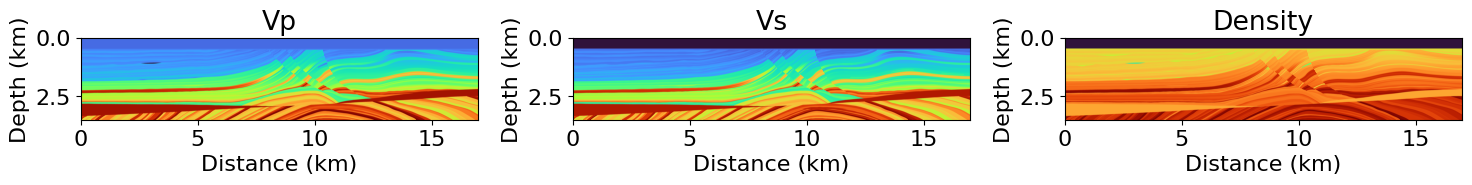

In [ ]:
dx, dz = 1.249, 1.249
nx, nz = 13601, 2801

X = np.linspace(0, nx*dx, nx)
Z = np.linspace(0, nz*dz, nz)

vp = np.memmap(
    "./vp.rsf@",
    dtype=np.float32,
    shape=(nx, nz)
    ).T * 1e3

vs = np.memmap(
    "./vs.rsf@",
    dtype=np.float32,
    shape=(nx, nz)
    ).T * 1e3

density = np.memmap(
    "./density.rsf@",
    dtype=np.float32,
    shape=(nx, nz)
    ).T * 1e3

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(vp, cmap='turbo', extent=[0, nx*dx*1e-3, nz*dz*1e-3, 0])
axs[0].set_title('Vp')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('Depth (km)')

axs[1].imshow(vs, cmap='turbo', extent=[0, nx*dx*1e-3, nz*dz*1e-3, 0])
axs[1].set_title('Vs')
axs[1].set_xlabel('Distance (km)')
axs[1].set_ylabel('Depth (km)')

axs[2].imshow(density, cmap='turbo', extent=[0, nx*dx*1e-3, nz*dz*1e-3, 0])
axs[2].set_title('Density')
axs[2].set_xlabel('Distance (km)')
axs[2].set_ylabel('Depth (km)')
plt.tight_layout()
plt.show()

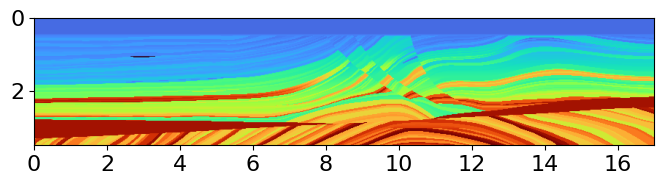

In [5]:
new_dx, new_dz = 20, 20
new_nx, new_nz = int(nx*dx/new_dx), int(nz*dz/new_dz)
X_new = np.linspace(0, nx*dx, new_nx)
Z_new = np.linspace(0, nz*dz, new_nz)

Xgrid, Zgrid = np.meshgrid(X_new, Z_new)

vp_new = RegularGridInterpolator((Z, X), vp, method='linear')((Zgrid, Xgrid))
vs_new = RegularGridInterpolator((Z, X), vs, method='linear')((Zgrid, Xgrid))
density_new = RegularGridInterpolator((Z, X), density, method='linear')((Zgrid, Xgrid))

plt.imshow(vp_new, cmap='turbo', extent=[0, nx*dx*1e-3, nz*dz*1e-3, 0])
plt.show()

Grid Points per Min Wavelength: 10.279998779296875
dt: 0.0015044825131628667


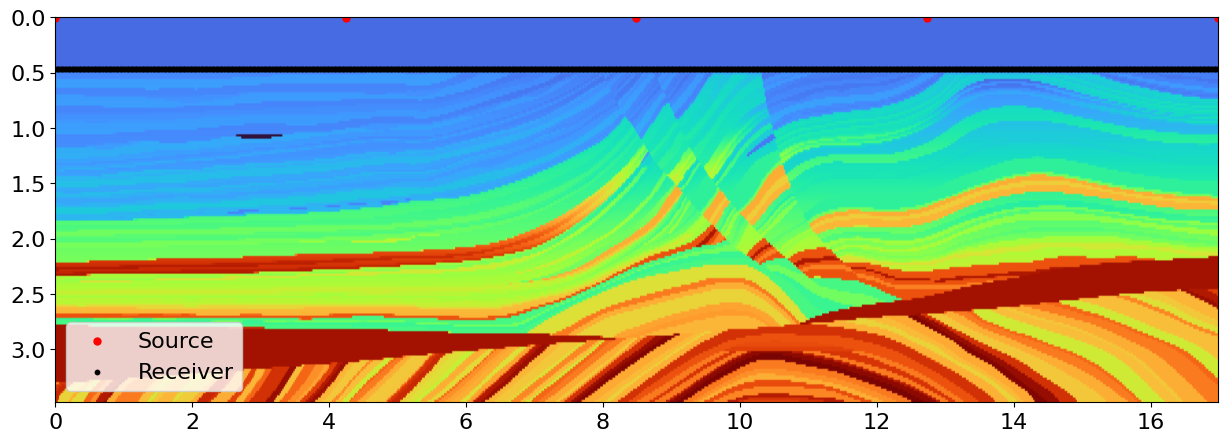

In [8]:
nbl = 40
shape = (new_nx, new_nz)
spacing = (new_dx, new_dz)
origin = (0., 0.)

nshots = 5
src_x = np.linspace(0, new_nx*new_dx, nshots)
src_z = np.ones_like(src_x) * 10
src_coords = np.column_stack((src_x, src_z))

rec_x = np.linspace(0, new_nx*new_dx, new_nx)
rec_z = np.ones_like(rec_x) * 470
rec_coords = np.column_stack((rec_x, rec_z))

f0 = 0.005

gp_per_lambda = np.min(vp_new) / (f0 * 1e3 * new_dx)
print(f'Grid Points per Min Wavelength: {gp_per_lambda}')

v_max = np.max(vp_new)
dt = .5 * min(new_dx, new_dz) / (np.sqrt(2) * v_max)
print(f'dt: {dt}')
t_max = 4.0

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.imshow(vp_new, cmap='turbo', extent=[0, new_nx*new_dx*1e-3, new_nz*new_dz*1e-3, 0], aspect='auto')
ax.scatter(src_coords[:, 0]*1e-3, src_coords[:, 1]*1e-3, color='red', s=25, label='Source')
ax.scatter(rec_coords[:, 0]*1e-3, rec_coords[:, 1]*1e-3, color='black', s=10, label='Receiver')
ax.legend()
plt.show()


In [9]:
shot_gathers_vx = []
shot_gathers_vz = []

for i, coord in enumerate(src_coords):
    print(f"Simulating Shot {i+1} at x={coord[0]}m...")
    
    current_src_coords = src_coords[i:i+1] 

    d_vx, d_vz = forward_elastic(
        vp_new.T, vs_new.T, density_new.T, 
        new_dx, new_dz,
        src_coords=current_src_coords, 
        rec_coords=rec_coords, 
        f0=f0,
        dt=dt,
        t_max=t_max,
        nbl=nbl,
    )
    
    shot_gathers_vx.append(np.array(d_vx))
    shot_gathers_vz.append(np.array(d_vz))

Simulating Shot 1 at x=0.0m...
(18560, 4260)


Operator `Kernel` ran in 1.08 s


Simulating Shot 2 at x=4245.0m...
(18560, 4260)


Operator `Kernel` ran in 1.10 s


Simulating Shot 3 at x=8490.0m...
(18560, 4260)


Operator `Kernel` ran in 1.10 s


Simulating Shot 4 at x=12735.0m...
(18560, 4260)


Operator `Kernel` ran in 1.08 s


Simulating Shot 5 at x=16980.0m...
(18560, 4260)


Operator `Kernel` ran in 1.04 s


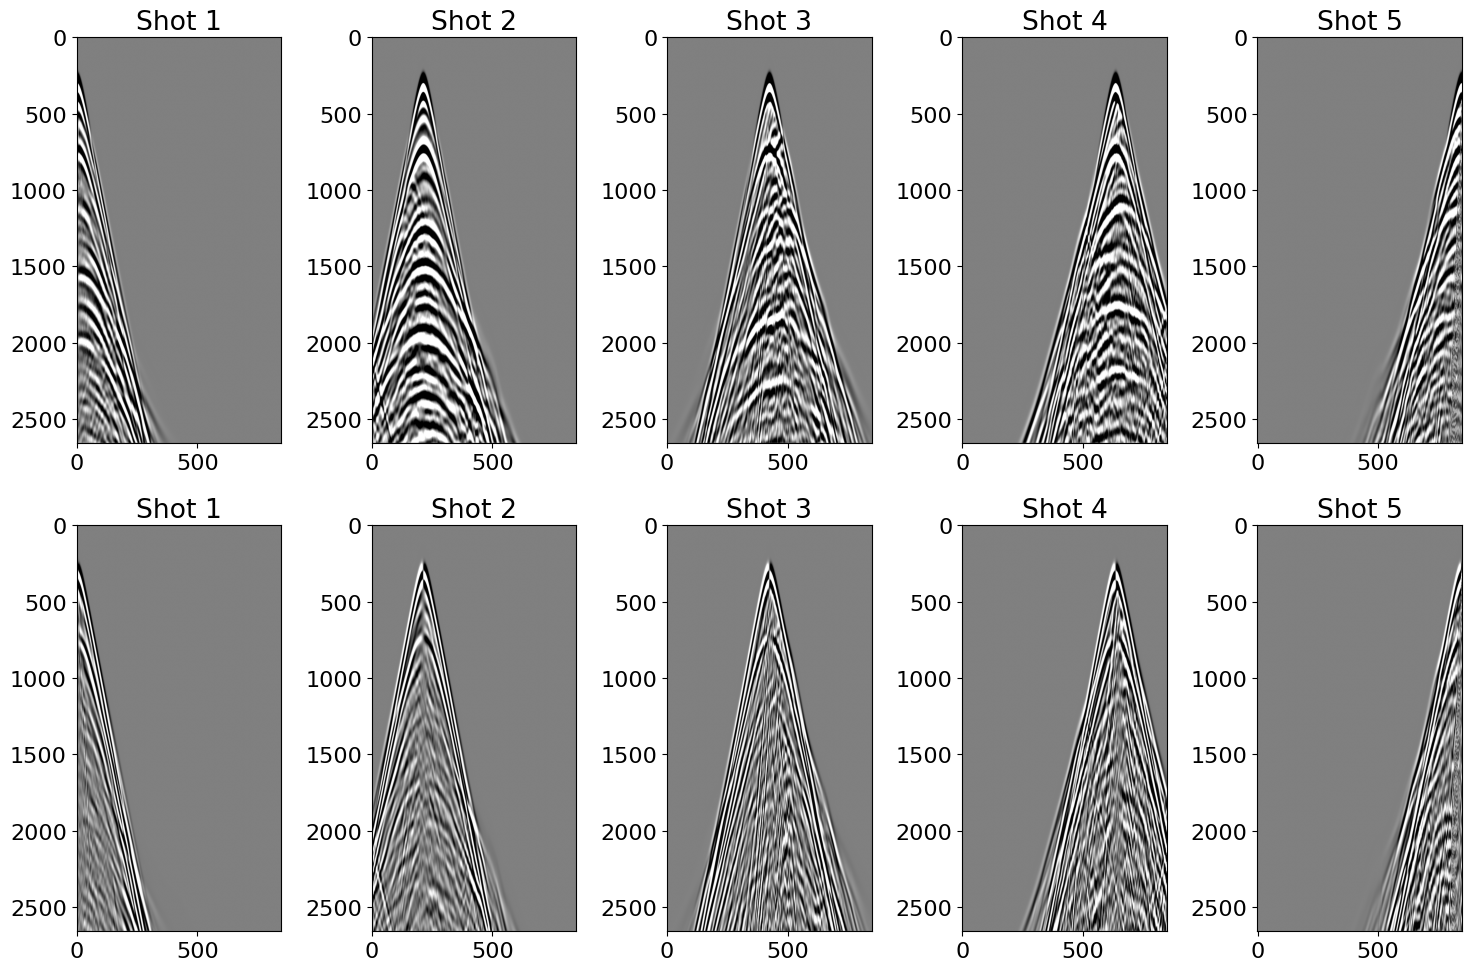

In [10]:
final_data_vz = np.array(shot_gathers_vz)
final_data_vx = np.array(shot_gathers_vx)

scale = np.percentile(np.abs(final_data_vz), 90)

fig, ax = plt.subplots(2, 5, figsize=(15, 10))
for i in range(5):
    ax[0, i].imshow(final_data_vz[i], aspect='auto', cmap='gray', vmin=-scale, vmax=scale)
    ax[0, i].set_title(f'Shot {i+1}')
    ax[1, i].imshow(final_data_vx[i], aspect='auto', cmap='gray', vmin=-scale, vmax=scale)
    ax[1, i].set_title(f'Shot {i+1}')
plt.tight_layout()
plt.show()